## Importing the necessary libraries

In [205]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from thefuzz import process, fuzz
import re
import unicodedata



# Data preparation

## 1-Data Inspection

#### Load data

In [206]:
df_hit=pd.read_csv('homeintunisia_appartement_location.csv')

In [207]:
df_mub_location=pd.read_csv('mubawab_apartement_location.csv')

In [208]:
df_mub_vacanes=pd.read_csv('mubawab_apartement_vacance.csv')

In [209]:
df_remax=pd.read_csv('remax_apartement_location.csv')

#### Inspect data

In [210]:
df_hit.head(3)

,link,title,address,price,type,Référence,Pièces,Surface,Surface totale,Type de chauffage,...,Terrasse 16 m²,Cour 15 m²,Faux plafond,Jeu de boules,Balcon 8 m²,Chambre 12 m²,Chambre 17 m²,Balcon 6 m²,Séjour,Balcons
0,https://www.homeintunisia.com/fr/propri%C3%A9t...,Location Saisonnière – Appartement S+2 à,Tantana,220 TND / Jour,Appartement,85860744,3 pièces,92 m²,NaN,"Radiateur, Climatisation",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.homeintunisia.com/fr/propri%C3%A9t...,Location annuelle d’un appartement s+2 à Kheza...,Sousse Khezama,850 TND / Mois,Appartement,85859019,3 pièces,150 m²,NaN,Sans chauffage,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.homeintunisia.com/fr/propri%C3%A9t...,location Saisonnière S+1 avec terrasse à chatt...,Chatt Meriem,À partir de 180 TND / Jour,Appartement,85901488,2 pièces,40 m²,NaN,Climatisation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### shape of the data (number of rows, number of columns)

In [211]:
df_hit.shape

(463, 142)

In [212]:
df_mub_location.shape

(2654, 51)

In [213]:
df_mub_vacanes.shape

(273, 49)

In [214]:
df_remax.shape

(72, 101)

In [215]:
euro_to_dinar=3.38

##### column names

In [216]:
df_hit.columns

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       ...
       'Terrasse 16 m²', 'Cour 15 m²', 'Faux plafond', 'Jeu de boules',
       'Balcon 8 m²', 'Chambre 12 m²', 'Chambre 17 m²', 'Balcon 6 m²',
       'Séjour', 'Balcons'],
      dtype='object', length=142)

In [217]:
df_remax.columns

Index(['link', 'title', 'prix', 'payment_method', 'latitude', 'longitude',
       'address', 'statut_marche', 'Nombre de pièces', 'Nombre de chambres',
       ...
       'Art Deco', 'Art moderne', 'Microwave', 'Pieds dans l'eau',
       'Vue sur mer', 'Sur route fréquentée', 'Zone commerciale',
       'Surface du terrain', 'Terrasse sur le toit', 'En bordure de forêt'],
      dtype='object', length=101)

In [218]:
df_mub_location.columns

Index(['link', 'title', 'address', 'price', 'm²', 'Pièces', 'Chambre',
       'Salle de bain', 'Jardin', 'Meublé', 'Climatisation',
       'Chauffage central', 'Cuisine équipée', 'Machine à laver',
       'Type de bien', 'Etat', 'latitude', 'longitude', 'Pièce', 'Chambres',
       'Surface habitable', 'Surface extérieure', 'Terrasse', 'Vue sur mer',
       'Façade extérieure', 'Salon européen', 'Antenne parabolique',
       'Sécurité', 'Double vitrage', 'Porte blindée', 'Réfrigérateur', 'Four',
       'TV', 'Micro-ondes', 'Internet', 'Animaux domestiques autorisés',
       'Etat du bien', 'Type du sol', 'Garage', 'Ascenseur',
       'Vue sur les montagnes', 'Concierge', 'Chambre rangement',
       'Étage du bien', 'Orientation', 'Salles de bains', 'Piscine',
       'Cheminée', 'État', 'Livraison:', 'Standing'],
      dtype='object')

#### matching columns

In [219]:
cols_mub=['price','address', 'm²','Pièces','Salle de bain', 'Terrasse',
         'Ascenseur', 'Meublé','Climatisation','Chauffage central', 'Sécurité',
         'Étage du bien','latitude', 'longitude', 'Chambres', 'Garage', 'Jardin', 'Piscine',
        'Surface habitable', 'Salles de bains']
cols_renamed = {
    'm²': 'total_area',
    'Surface habitable':  'living_area',
    'Pièces': 'rooms',
    'Chambres': 'bedrooms',
    'Salles de bains': 'bathrooms',
    'Salle de bain': 'bathroom',
    'Jardin': 'garden',
    'Garage': 'garage',
    'Piscine': 'pool',
    'Chauffage central': 'heating',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'Terrasse': 'terrace',
    'Climatisation': 'air_conditioning',
    'Surface de la parcelle': 'total_area',  #
    'Meublé': 'furnished',
    "Sécurité":"security",
    "Ascenseur":"elevator",
    'Étage du bien':"floor_number"
}
# Assuming df is your DataFrame
df_mub_location = df_mub_location[cols_mub].rename(columns=cols_renamed)
df_mub_location["payment_period"]="Mois"
df_mub_location.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathroom', 'terrace',
       'elevator', 'furnished', 'air_conditioning', 'heating', 'security',
       'floor_number', 'latitude', 'longitude', 'bedrooms', 'garage', 'garden',
       'pool', 'living_area', 'bathrooms', 'payment_period'],
      dtype='object')

In [220]:
df_mub_vacanes['Meublé']=1
df_mub_vacanes= df_mub_vacanes[cols_mub].rename(columns=cols_renamed)
df_mub_vacanes.columns


Index(['price', 'address', 'total_area', 'rooms', 'bathroom', 'terrace',
       'elevator', 'furnished', 'air_conditioning', 'heating', 'security',
       'floor_number', 'latitude', 'longitude', 'bedrooms', 'garage', 'garden',
       'pool', 'living_area', 'bathrooms'],
      dtype='object')

In [221]:
hit_cols=df_hit.columns
hit_cols[90::]

Index(['Lave-vaisselle', 'Immeuble classé/inscrit', 'Télédistribution',
       'Groupe électrogène', 'Sèche-cheveux', 'Sèche-linge', 'Téléphone',
       'Terrain 1400 m²', 'Buanderie commune', 'Jardin 500 m²',
       'Panneaux photovoltaïques', 'Terrain 2500 m²', 'Concierge',
       'Moustiquaires', 'Salons', 'Garage', 'Lecteur DVD', 'Lecteur CD',
       'Ascenseur', 'Piscine en copropriété', 'Fibre optique', 'Digicode',
       'Coffre-fort', 'Terrasse', 'Suite', 'Terrasse 90 m²', 'Balcon',
       'Salle de sport', 'Cour', 'Local à vélo', 'Terrasse 300 m²',
       'Domotique', 'Ventilation double flux', 'Sauna', 'Spa',
       'Abri de jardin 72 m²', 'Studio 48 m²', 'Golf', 'Tennis',
       'Terrasse 60 m²', 'Parking', 'Appartement 122 m²', 'Terrasse 16 m²',
       'Cour 15 m²', 'Faux plafond', 'Jeu de boules', 'Balcon 8 m²',
       'Chambre 12 m²', 'Chambre 17 m²', 'Balcon 6 m²', 'Séjour', 'Balcons'],
      dtype='object')

In [222]:
cols_hit=['price','address','Pièces','Surface','Surface totale','Salles de bains','Salle de bains'
                    ,'Étage','Type de chauffage','Piscine','latitude','longitude',
                    'Air conditionné','Meublé','Ascenseur','Piscine en copropriété',
                    'Terrasse','Alarme','Vidéo surveillance','Garage','Jardin']
df_hit=df_hit[cols_hit]
# Using pandas rename method directly
df_hit = df_hit.rename(columns={
    'Pièces': 'rooms',
    'Surface': 'living_area',
    'Surface totale': 'total_area',
    'Étage': 'floor',
    'Salon': 'living_room',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Ascenseur': 'elevator',
    'Piscine en copropriété': 'shared_pool',
    'Salles de bains':'bathrooms',
    'Salle de bains':'bathroom',
    'Type de chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'alarm',
    'Vidéo surveillance':'video_surveillance',
    'Garage':'garage',
    'Jardin':'garden'
})
df_hit.columns

Index(['price', 'address', 'rooms', 'living_area', 'total_area', 'bathrooms',
       'bathroom', 'floor', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'elevator', 'shared_pool', 'terrace',
       'alarm', 'video_surveillance', 'garage', 'garden'],
      dtype='object')

In [223]:
cols_remax=["prix",'address',"payment_method",'latitude','longitude',"Nombre de pièces",
            "m²","Surface Terrain (m²)","Nombre d'étages","Meublé","Air Conditionné","Ascenseur",
            'Chauffage','Chauffage au sol','Chauffage Central','Nombre salles de bain',
            "Système d'alarme",'Système de sécurité', 'Système de surveillance','Camera de sécurité',
            'Garage',"Terrasse","Jardin"]
df_remax=df_remax[cols_remax]
df_remax = df_remax.rename(columns={
    "prix":"price",
    "payment_method":"payment_period",
    'Nombre de pièces': 'rooms',
    'm²': 'living_area',
    'Surface Terrain (m²)': 'total_area',
    'État': 'condition',
    "Nombre d'étages": 'floor_number',
    'Salon': 'living_room',
    'Air Conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Ascenseur': 'elevator',
    "Garage": "garage",
    "Jardin": "garden",
    "Terrasse": "terrace",
    "Nombre salles de bain":"bathrooms_number"
})
df_remax["pool"]=None
df_remax.columns

Index(['price', 'address', 'payment_period', 'latitude', 'longitude', 'rooms',
       'living_area', 'total_area', 'floor_number', 'furnished',
       'air_conditioning', 'elevator', 'Chauffage', 'Chauffage au sol',
       'Chauffage Central', 'bathrooms_number', 'Système d'alarme',
       'Système de sécurité', 'Système de surveillance', 'Camera de sécurité',
       'garage', 'terrace', 'garden', 'pool'],
      dtype='object')

## 2- Data Cleaning

### a-standardizing Formats

-df_hit

In [224]:
df_hit["price"].head(10)

0                220 TND / Jour
1                850 TND / Mois
2    À partir de 180 TND / Jour
3    À partir de 230 TND / Jour
4              1 800 TND / Mois
5              1 000 TND / Mois
6              1 600 TND / Mois
7              1 500 TND / Mois
8              1 200 TND / Mois
9              1 200 TND / Jour
Name: price, dtype: object

In [225]:
print(df_hit.shape)
df_hit=df_hit[df_hit['price']!="Prix sur demande"]
print(df_hit.shape)

(463, 21)
(449, 21)


In [226]:
# Function to extract both price value and payment period from price column
def extract_price_info(price_str):
    """
    -r'([0-9\s\u202f]+(?:[,.]\d+)?)\s*(?:TND)' : 
      It looks for digits, spaces, or special space characters
      Followed by optional decimal part
      Followed by "TND"
      exemple : À partir de 500 TND / Jour => group(1) gives us 500
    -re.search(r'/\s*(\w+)', price_str):
        The pattern finds the slash "/"
        Skips any spaces after the slash
        Captures "Jour/Semaine/Mois" in the group (\w+)
    """
    if not isinstance(price_str, str):
        return None, None   
    # Extract numeric part and payment period
    price_match = re.search(r'([0-9\s\u202f]+(?:[,.]\d+)?)\s*(?:TND)', price_str)
    period_match = re.search(r'/\s*(\w+)', price_str)
    price_value = None
    if price_match:
        # Clean and normalize the price string
        price = price_match.group(1).strip()
        price = unicodedata.normalize('NFKD', price)
        price = re.sub(r'\s', '', price)
        price = price.replace(',', '.')
        
        try:
            price_value = float(price)
        except ValueError:
            print(f"Could not convert: {price} from original: {price_str}")
    
    # Extract period (Jour, Mois, Semaine, etc.)
    payment_period = period_match.group(1) if period_match else None
    
    return price_value, payment_period

df_hit['payment_period'] = None

for idx, row in df_hit.iterrows():
    price_value, period = extract_price_info(row['price'])
    if price_value is not None:
        df_hit.at[idx, 'price'] = price_value  # Update price column directly
    df_hit.at[idx, 'payment_period'] = period

# Display the results
print(df_hit[['price', 'payment_period']].head())

    price payment_period
0   220.0           Jour
1   850.0           Mois
2   180.0           Jour
3   230.0           Jour
4  1800.0           Mois


In [227]:
df_hit['price']=df_hit['price'].astype(float)
print(df_hit[['price', 'payment_period']].head(10))

    price payment_period
0   220.0           Jour
1   850.0           Mois
2   180.0           Jour
3   230.0           Jour
4  1800.0           Mois
5  1000.0           Mois
6  1600.0           Mois
7  1500.0           Mois
8  1200.0           Mois
9  1200.0           Jour


In [228]:
df_hit['payment_period'].value_counts()

payment_period
Jour       250
Mois       160
Semaine     38
Name: count, dtype: int64

In [229]:
df_hit['rooms'].value_counts()

rooms
3 pièces     219
2 pièces     140
4 pièces      48
1 pièce       27
5 pièces       4
6 pièces       2
7 pièces       1
10 pièces      1
Name: count, dtype: int64

In [230]:
df_hit['rooms']=df_hit['rooms'].str.replace(' pièces','')
df_hit['rooms']=df_hit['rooms'].str.replace(' pièce','')
df_hit['rooms']=df_hit['rooms'].astype(float)
df_hit['rooms'].value_counts()

rooms
3.0     219
2.0     140
4.0      48
1.0      27
5.0       4
6.0       2
7.0       1
10.0      1
Name: count, dtype: int64

In [231]:
print(df_hit['total_area'].value_counts().head(3))
print(df_hit['living_area'].value_counts().head(3))

total_area
80 m²     14
100 m²    11
70 m²      8
Name: count, dtype: int64
living_area
80 m²     78
100 m²    53
60 m²     43
Name: count, dtype: int64


In [232]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['living_area', 'total_area']
for col in columns_to_transform:
    df_hit = clean_size_column(df_hit, col)
df_hit[columns_to_transform].sample(5)


,living_area,total_area
137,89.0,100.0
29,250.0,350.0
4,100.0,NaN
96,200.0,230.0
436,NaN,NaN


In [233]:
df_hit['pool'] = df_hit[['pool', 'shared_pool']].max(axis=1)
df_hit.drop(columns=['shared_pool'],inplace=True)

In [234]:
df_hit['bathrooms_number'] = df_hit[['bathroom', 'bathrooms']].max(axis=1)
df_hit.drop(columns=['bathrooms', 'bathroom'],inplace=True)

In [235]:
df_hit['security']=0
df_hit['security']=df_hit[['video_surveillance', 'alarm']].max(axis=1)
df_hit=df_hit.drop(columns=['video_surveillance', 'alarm'],axis=1)
df_hit.columns

Index(['price', 'address', 'rooms', 'living_area', 'total_area', 'floor',
       'heating', 'pool', 'latitude', 'longitude', 'air_conditioning',
       'furnished', 'elevator', 'terrace', 'garage', 'garden',
       'payment_period', 'bathrooms_number', 'security'],
      dtype='object')

In [236]:
# Set to 1 for properties with any type of heating
df_hit["heating"]=df_hit["heating"].fillna(0)
df_hit["heating"]=df_hit["heating"].apply(lambda x: 0 if x=="Sans chauffage" else 1)
print(df_hit['heating'].value_counts())

heating
1    444
0      5
Name: count, dtype: int64


In [237]:
# Create two new columns
df_hit['floor_number'] = None
# Function to extract floor number
def extract_floor_number(floor_str):
    if not isinstance(floor_str, str):
        return None
        
    # Handle special cases
    if 'Rez-de-chaussée' in floor_str or 'Rez-de-jardin' in floor_str:
        return 0
    if 'Plain-pied' in floor_str:
        return 0
    if 'Surélevé' in floor_str:
        return 0.5
        
    # Extract floor number from strings like "1er", "2ème", etc.
    match = re.search(r'^(\d+)', floor_str)
    if match:
        return int(match.group(1))
        
    # Extract from patterns like "2ème étage / 4"
    match = re.search(r'^(\d+)[^\d]+', floor_str)
    if match:
        return int(match.group(1))
        
    return None

# Apply the functions
df_hit['floor_number'] = df_hit['floor'].apply(extract_floor_number)
# Check the results
df_hit=df_hit.drop(columns=['floor'],axis=1)
df_hit['floor_number']=df_hit['floor_number'].astype(float)
df_hit['floor_number'].head()

0    4.0
1    1.0
2    3.0
3    NaN
4    0.0
Name: floor_number, dtype: float64

df_mub

In [238]:
print(df_mub_vacanes.shape)
df_mub_vacanes=df_mub_vacanes[df_mub_vacanes['price']!="Prix à consulter"]
print(df_mub_vacanes.shape)

(273, 20)
(215, 20)


In [239]:
df_mub_vacanes['price'].head(10)

0     2 900 TND par semaine
2                   180 TND
3     2 900 TND par semaine
4     1 950 TND par semaine
5                    90 TND
6          300 TND par jour
7                   250 TND
9                    80 TND
10    3 500 TND par semaine
12    1 850 TND par semaine
Name: price, dtype: object

In [240]:
df_mub_vacanes['payment_period'] = None
for idx, row in df_mub_vacanes.iterrows():
    price_ch = df_mub_vacanes.loc[idx, 'price']
    position = price_ch.find('TND')
    if position !=-1:
        price = price_ch[0:position].rstrip()
        price=price.replace(' ','')
        price=float(price)
        if "jour" in price_ch:
            payment_period="Jour"
        elif "semaine" in price_ch:
            payment_period="Semaine"
        else:
            payment_period=None
    else:
        position = price_ch.find('EUR')
        price = price_ch[0:position].rstrip()
        price=price.replace(' ','')
        price=float(price) * euro_to_dinar
        if "jour" in price_ch:
            payment_period="Jour"
        elif "semaine" in price_ch:
            payment_period="Semaine"
        else:
            payment_period=None
    df_mub_vacanes.loc[idx, "payment_period"] = payment_period
    df_mub_vacanes.loc[idx, "price"] = price

In [241]:
df_mub_vacanes['payment_period'].value_counts()

payment_period
Jour       95
Semaine    70
Name: count, dtype: int64

In [242]:
df_mub_vacanes['price']=df_mub_vacanes['price'].astype(float)
df_mub_vacanes['price'].head(10)

0     2900.0
2      180.0
3     2900.0
4     1950.0
5       90.0
6      300.0
7      250.0
9       80.0
10    3500.0
12    1850.0
Name: price, dtype: float64

In [243]:
df_mub_location=df_mub_location[df_mub_location['price']!="Prix à consulter"]
df_mub_location['price']=df_mub_location['price'].str.replace('TND','')
df_mub_location['price']=df_mub_location['price'].str.replace(' ','')
# Function to extract the first price value
def extract_first_price(price_str):
    # Pattern to match the first number followed by TND
    idx=price_str.find("B")
    if idx!=-1:
        price_str=price_str[:idx]
    return price_str
# To apply to the entire price column:
df_mub_location["price"] = df_mub_location["price"].apply(extract_first_price)

In [244]:
df_mub_location['price']=df_mub_location['price'].astype(float)

In [245]:
df_mub=pd.concat([df_mub_vacanes,df_mub_location])
df_mub.shape

(2685, 21)

In [246]:
df_mub['bathrooms_number']=df_mub[['bathroom', 'bathrooms']].max(axis=1)
df_mub=df_mub.drop(columns=['bathrooms', 'bathroom'], axis=1)

In [247]:
df_mub['floor_number'].value_counts()

floor_number
1er      289
2ème     236
3ème     146
4ème      75
5ème      48
6ème      30
7ème      17
8ème       5
18ème      3
10ème      2
20ème      2
16ème      1
9ème       1
Name: count, dtype: int64

In [248]:
df_mub['floor_number']=df_mub["floor_number"].str.replace('ème','')
df_mub['floor_number']=df_mub["floor_number"].str.replace('er','')
df_mub['floor_number']=df_mub['floor_number'].astype(float)
df_mub['floor_number'].value_counts()

floor_number
1.0     289
2.0     236
3.0     146
4.0      75
5.0      48
6.0      30
7.0      17
8.0       5
18.0      3
10.0      2
20.0      2
16.0      1
9.0       1
Name: count, dtype: int64

In [249]:
df_mub['total_area'].sample(3)

1418    110.0
70       26.0
229     100.0
Name: total_area, dtype: float64

In [250]:
df_mub['living_area'].sample(3)

2063    NaN
764     NaN
1232    NaN
Name: living_area, dtype: object

In [251]:
print(df_mub.shape)
df_mub=clean_size_column(df_mub, 'living_area')
print(df_mub.shape)

(2685, 20)
(2685, 20)


df_remax

In [252]:
df_remax.columns

Index(['price', 'address', 'payment_period', 'latitude', 'longitude', 'rooms',
       'living_area', 'total_area', 'floor_number', 'furnished',
       'air_conditioning', 'elevator', 'Chauffage', 'Chauffage au sol',
       'Chauffage Central', 'bathrooms_number', 'Système d'alarme',
       'Système de sécurité', 'Système de surveillance', 'Camera de sécurité',
       'garage', 'terrace', 'garden', 'pool'],
      dtype='object')

In [253]:
df_remax['heating']=0
df_remax['heating'] = df_remax[['Chauffage','Chauffage au sol','Chauffage Central']].max(axis=1)
df_remax.drop(columns=['Chauffage au sol','Chauffage Central','Chauffage'],inplace=True)

In [254]:
df_remax['security']=0
df_remax['security'] = df_remax[['Système de sécurité','Système de surveillance', 'Camera de sécurité',"Système d'alarme"]].max(axis=1)
df_remax.drop(columns=['Système de sécurité','Système de surveillance', 'Camera de sécurité',"Système d'alarme"],inplace=True)
df_remax.columns

Index(['price', 'address', 'payment_period', 'latitude', 'longitude', 'rooms',
       'living_area', 'total_area', 'floor_number', 'furnished',
       'air_conditioning', 'elevator', 'bathrooms_number', 'garage', 'terrace',
       'garden', 'pool', 'heating', 'security'],
      dtype='object')

In [255]:
df_remax=df_remax[df_remax['price']!='Nous consulter']
df_remax['price']=df_remax['price'].str.replace(' TND','')
df_remax['price']=df_remax['price'].str.replace(',','')
df_remax['price']=df_remax['price'].astype(float)

In [256]:
df_remax['payment_period'].value_counts()

payment_period
[Mensuellement]         45
[Par mois + Charges]    15
[Par an + Charges]       9
Name: count, dtype: int64

In [257]:
df_remax['payment_period']=df_remax['payment_period'].str.replace('[Mensuellement]', 'Mois')
df_remax['payment_period']=df_remax['payment_period'].str.replace('[Par mois + Charges]', 'Mois')
df_remax['payment_period']=df_remax['payment_period'].str.replace('[Par an + Charges]', 'Mois')

In [258]:
df_remax.columns

Index(['price', 'address', 'payment_period', 'latitude', 'longitude', 'rooms',
       'living_area', 'total_area', 'floor_number', 'furnished',
       'air_conditioning', 'elevator', 'bathrooms_number', 'garage', 'terrace',
       'garden', 'pool', 'heating', 'security'],
      dtype='object')

new dataframe

In [259]:
df=pd.concat([df_mub,df_hit,df_remax])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3203 entries, 0 to 71
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             3203 non-null   float64
 1   address           3203 non-null   object 
 2   total_area        2429 non-null   float64
 3   rooms             2506 non-null   float64
 4   terrace           1823 non-null   float64
 5   elevator          1312 non-null   float64
 6   furnished         1755 non-null   float64
 7   air_conditioning  2381 non-null   float64
 8   heating           2408 non-null   float64
 9   security          1569 non-null   float64
 10  floor_number      1337 non-null   float64
 11  latitude          3182 non-null   float64
 12  longitude         3182 non-null   float64
 13  bedrooms          1984 non-null   float64
 14  garage            1316 non-null   float64
 15  garden            469 non-null    float64
 16  pool              431 non-null    float64
 17  li

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\1031403530.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df_mub,df_hit,df_remax])


### b-handle missing values

#### Droping columns with high missing values 

In [260]:
df.isna().sum().sort_values(ascending=False)

pool                2772
garden              2734
living_area         2454
elevator            1891
garage              1887
floor_number        1866
security            1634
furnished           1448
terrace             1380
bedrooms            1219
air_conditioning     822
heating              795
total_area           774
rooms                697
bathrooms_number     688
payment_period        51
longitude             21
latitude              21
address                0
price                  0
dtype: int64

pool/elevator/air_conditioning/furnished/heating NaN values means 0

In [261]:
percentage_missing=df.isnull().sum()*100/len(df)
percentage_missing.sort_values(ascending=False)

pool                86.543865
garden              85.357477
living_area         76.615673
elevator            59.038401
garage              58.913519
floor_number        58.257883
security            51.014674
furnished           45.207618
terrace             43.084608
bedrooms            38.058071
air_conditioning    25.663441
heating             24.820481
total_area          24.164845
rooms               21.760849
bathrooms_number    21.479863
payment_period       1.592257
longitude            0.655635
latitude             0.655635
address              0.000000
price                0.000000
dtype: float64

In [262]:
df_clean=df.copy()

#### Replace missing values with mean,mode,median,0 or 1
mode => categorical distribution

median => skewed distribution

mean => normal distribution

0/1 => when we know that the value is normally 1 or 0

In [263]:
columns_with_zeros=['pool','garden','elevator','garage','security','terrace','bedrooms',
                    'air_conditioning','heating','furnished']
for col in columns_with_zeros:
    df_clean[col]=df_clean[col].fillna(0)
columns_with_one=['bathrooms_number']
for col in columns_with_one:
    df_clean[col]=df_clean[col].fillna(1)

In [264]:
mode_columns=["rooms","floor_number"]
for col in mode_columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\4238981637.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


In [265]:
# Fill missing values
df_clean['total_area'] = df_clean['total_area'].fillna(df_clean['living_area'])
df_clean=df_clean.drop(columns=['living_area'],axis=1)
df_clean.isna().sum().sort_values(ascending=False)

total_area          432
payment_period       51
longitude            21
latitude             21
price                 0
floor_number          0
pool                  0
garden                0
garage                0
bedrooms              0
security              0
address               0
heating               0
air_conditioning      0
furnished             0
elevator              0
terrace               0
rooms                 0
bathrooms_number      0
dtype: int64

In [266]:
def plot_distribution(data,title,xlabel):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True)  # kde=True will add a kernel density estimate curve to visualize distribution smoothly
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.show()

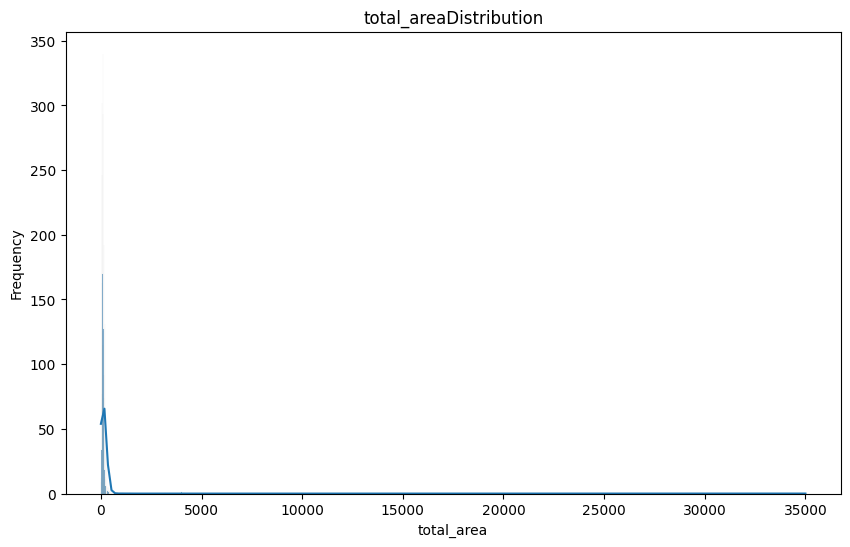

In [267]:
for col in ['total_area']:
    plot_distribution(df_clean[col],col + 'Distribution',col)

In [268]:
df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\2492172101.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)


In [269]:
print(df_clean.shape)
df_clean=df_clean.dropna(subset=['payment_period'])
print(df_clean.shape)

(3203, 19)
(3152, 19)


### c- Handling outliers

For removing outliers we have to consider 2 things , the place and the payment period 

In [270]:
print(df_clean.shape)
print(df_clean['price'].min())
print(df_clean['price'].max())

(3152, 19)
60.0
1300000.0


In [271]:
df_clean=df_clean[df_clean['price']<9999]
print(df_clean.shape)

(3135, 19)


In [272]:
municipality_df=pd.read_csv('municipalities.csv')
municipality_df.head()

,governorate,municipality
0,Tunis,Tunis
1,Tunis,Le Bardo
2,Tunis,Le Kram
3,Tunis,La Goulette
4,Tunis,Carthage


In [273]:
print(municipality_df['governorate'].nunique())
print(municipality_df['governorate'].unique())

24
['Tunis' 'Ariana' 'Ben Arous' 'Manouba' 'Nabeul' 'Zaghouan' 'Bizerte'
 'Béja' 'Jendouba' 'Kef' 'Siliana' 'Sousse' 'Monastir' 'Mahdia' 'Sfax'
 'Kairouan' 'Kasserine' 'Sidi Bouzid' 'Gabès' 'Mednine' 'Tataouine'
 'Gafsa' 'Tozeur' 'Kebili']


In [274]:
print(municipality_df['municipality'].nunique())
print(municipality_df['municipality'].unique())

270
['Tunis' 'Le Bardo' 'Le Kram' 'La Goulette' 'Carthage' 'Sidi Bou Said'
 'La Marsa' 'Sidi Hassine' 'Ariana' 'La Soukra' 'Raoued'
 'Kalâat el-Andalous' 'Sidi Thabet' 'Ettadhamen-Mnihla' 'Ben Arous'
 'El Mourouj' 'Hammam Lif' 'Hammam Chott' 'Bou Mhel el-Bassatine'
 'Ezzahra' 'Radès' 'Mégrine' 'Mohamedia-Fouchana' 'Mornag' 'Khalidia'
 'Manouba' 'Den Den' 'Douar Hicher' 'Oued Ellil' 'Mornaguia'
 'Borj El Amri' 'Djedeida' 'Tebourba' 'El Battan' 'Nabeul' 'Dar Chaabane'
 'Béni Khiar' 'El Maâmoura' 'Somâa' 'Korba' 'Tazerka' 'Menzel Temime'
 'Menzel Horr' 'El Mida' 'Kelibia' 'Azmour' 'Hammam Ghezèze' 'Dar Allouch'
 'El Haouaria' 'Takelsa' 'Soliman' 'Korbous' 'Menzel Bouzelfa'
 'Béni Khalled' 'Zaouiet Djedidi' 'Grombalia' 'Bou Argoub' 'Hammamet'
 'Zaghouan' 'Zriba' 'Bir Mcherga' 'Djebel Oust' 'El Fahs' 'Nadhour'
 'Bizerte' 'Sejnane' 'Mateur' 'Menzel Bourguiba' 'Tinja' 'Ghar al Milh'
 'Aousja' 'Menzel Jemil' 'Menzel Abderrahmane' 'El Alia' 'Ras Jebel'
 'Metline' 'Raf Raf' 'Béja' 'El Maâgoula' 

In [275]:
df_clean["municipality"]=None
df_clean["governorate"]=None

In [276]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_municipality_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["municipality"],
                                             scorer=fuzz.partial_ratio)
    # Only return the municipality name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
df_clean["municipality"] = df_clean["address"].apply(get_municipality_if_good_match)

In [277]:
df_missing_municipality=df_clean[df_clean['municipality'].isna()]
df_full_municipality=df_clean[df_clean['municipality'].notna()]

In [278]:
# Function to get municipality from latitude and longitude
def get_municipality_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True,language="fr")
        address = location.raw['address']
        
        for field in ['municipality','city', 'town', 'village', 'suburb']:
            if field in address:
                return address[field]
        
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None

for idx, row in df_missing_municipality.iterrows():
    municipality = get_municipality_from_coords(row['latitude'], row['longitude'])
    if municipality:
        df_missing_municipality.at[idx, 'municipality'] = municipality
    else:
        df_missing_municipality.at[idx, 'municipality'] = df_missing_municipality.at[idx,'address']
    time.sleep(1)  # Sleep to respect API rate limits

In [279]:
df_clean=pd.concat([df_missing_municipality,df_full_municipality])

In [280]:
municipality_lst=list(municipality_df['municipality'])
governorate_lst=list(municipality_df['governorate'])
print(len(municipality_lst))
print(len(governorate_lst))

270
270


we fill governorate based on the municipality , exemple : Manar => Ariana

In [281]:
# a dictionary mapping municipalities to governorates
municipality_to_governorate = dict(zip(municipality_lst, governorate_lst))
print(municipality_to_governorate)
# update the governorate column using the mapping
df_clean['governorate'] = df_clean['municipality'].map(municipality_to_governorate)

{'Tunis': 'Tunis', 'Le Bardo': 'Tunis', 'Le Kram': 'Tunis', 'La Goulette': 'Tunis', 'Carthage': 'Tunis', 'Sidi Bou Said': 'Tunis', 'La Marsa': 'Tunis', 'Sidi Hassine': 'Tunis', 'Ariana': 'Ariana', 'La Soukra': 'Ariana', 'Raoued': 'Ariana', 'Kalâat el-Andalous': 'Ariana', 'Sidi Thabet': 'Ariana', 'Ettadhamen-Mnihla': 'Ariana', 'Ben Arous': 'Ben Arous', 'El Mourouj': 'Ben Arous', 'Hammam Lif': 'Ben Arous', 'Hammam Chott': 'Ben Arous', 'Bou Mhel el-Bassatine': 'Ben Arous', 'Ezzahra': 'Ben Arous', 'Radès': 'Ben Arous', 'Mégrine': 'Ben Arous', 'Mohamedia-Fouchana': 'Ben Arous', 'Mornag': 'Ben Arous', 'Khalidia': 'Ben Arous', 'Manouba': 'Manouba', 'Den Den': 'Manouba', 'Douar Hicher': 'Manouba', 'Oued Ellil': 'Manouba', 'Mornaguia': 'Manouba', 'Borj El Amri': 'Manouba', 'Djedeida': 'Manouba', 'Tebourba': 'Manouba', 'El Battan': 'Manouba', 'Nabeul': 'Nabeul', 'Dar Chaabane': 'Nabeul', 'Béni Khiar': 'Nabeul', 'El Maâmoura': 'Nabeul', 'Somâa': 'Nabeul', 'Korba': 'Nabeul', 'Tazerka': 'Nabeul', '

In [282]:
missing_governorate=df_clean[df_clean['governorate'].isnull()]
not_missing_governorate=df_clean[df_clean['governorate'].notna()]
print(len(missing_governorate))
print(len(not_missing_governorate))

96
3039


In [283]:
def get_governorate_from_municipality(municipality_name):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        # Search for the municipality name in Tunisia
        location = geolocator.geocode(f"{municipality_name}, Tunisia", exactly_one=True, language="fr")
        if location:
            address_details = geolocator.reverse((location.latitude, location.longitude), language="fr").raw['address']
            for field in ['state', 'county', 'region', 'province']:
                if field in address_details:
                    return address_details[field]
        return None
    except Exception as e:
        return None
def get_governorate_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True, language="fr")
        address = location.raw['address']
        
        for field in ['state', 'county', 'region', 'province']:
            if field in address:
                return address[field]
        return None
    except Exception as e:
        return None
# Apply the function to rows with missing governorate but known municipality
for idx, row in missing_governorate.iterrows():
    if pd.notna(row['municipality']):
        # First try using municipality name
        governorate = get_governorate_from_municipality(row['municipality'])
        # If that fails and we have coordinates, try using them
        if not governorate:
            governorate = get_governorate_from_coords(row['latitude'], row['longitude'])   
        if governorate:
            missing_governorate.at[idx, 'governorate'] = governorate
            
        time.sleep(1)  # Sleep to respect API rate limits

In [284]:
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Gouvernorat Sousse' 'Gouvernorat Ariana' 'Gouvernorat Nabeul'
 'Gouvernorat Monastir']


In [285]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_governorate_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["governorate"],
                                             scorer=fuzz.partial_ratio)
    # Only return the governorate name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\2345721556.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)


In [286]:
missing_governorate = missing_governorate.dropna(subset=['governorate'])
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Sousse' 'Ariana' 'Nabeul' 'Monastir']


In [287]:
print(df_clean.shape)
df_clean=pd.concat([missing_governorate,not_missing_governorate])
df_clean=df_clean.reset_index(drop=True)
print(df_clean.shape)

(3135, 21)
(3135, 21)


In [288]:
def clean_outliers(df):
    """
    This function is responsible for removing price outliers based on the prices arround property area
    prices are different from place to place
    -Initally we iniate outliers_mask a pandas series with false values , later we change outliers index
    to have a True value
    -In the end we filter our original dataset with non outliers
    """
    # First, let's check how many rows we have before removing outliers
    print("dataframe size before removing outliers: ", len(df))
    # Calculate IQR for each municipality and identify outliers
    outliers_mask = pd.Series(False, index=df.index)
    # Only process municipalities with enough data points
    min_properties = 5  # Minimum number of properties needed to calculate reliable statistics
    municipality_counts = df['municipality'].value_counts()
    valid_municipalities = municipality_counts[municipality_counts >= min_properties].index

    for municipality in valid_municipalities:
        # Get prices for this municipality
        municipality_prices = df[df['municipality'] == municipality]['price']
        
        # Calculate Q1, Q3 and IQR
        Q1 = municipality_prices.quantile(0.25)
        Q3 = municipality_prices.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds for outliers (typically 1.5 * IQR)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers for this municipality
        municipality_outliers = df[
            (df['municipality'] == municipality) & 
            ((df['price'] < lower_bound) | (df['price'] > upper_bound))
        ].index
        
        # Add to our overall outliers mask
        outliers_mask.loc[municipality_outliers] = True
        

    # For municipalities with too few properties, we can use global statistics
    small_municipalities = df['municipality'].isin(
        municipality_counts[municipality_counts < min_properties].index
    )

    if small_municipalities.sum() > 0:
        # Calculate global IQR
        all_prices = df['price']
        global_Q1 = all_prices.quantile(0.25)
        global_Q3 = all_prices.quantile(0.75)
        global_IQR = global_Q3 - global_Q1
        
        global_lower = global_Q1 - 1.5 * global_IQR
        global_upper = global_Q3 + 1.5 * global_IQR
        
        # Identify outliers in small municipalities
        small_muni_outliers = df[
            small_municipalities & 
            ((df['price'] < global_lower) | (df['price'] > global_upper))
        ].index
        
        # Add to our overall outliers mask
        outliers_mask.loc[small_muni_outliers] = True

    # Remove the outliers
    df_clean_no_outliers = df[~outliers_mask].copy() #outliers_mask is a boolean pandas series
    print(f"Dataframe size after removing outliers: ",len(df_clean_no_outliers))
    # Replace the original dataframe with the cleaned one
    return df_clean_no_outliers

In [289]:
df_day=df_clean[df_clean['payment_period']=='Jour']
df_month=df_clean[df_clean['payment_period']=='Mois']
df_week=df_clean[df_clean['payment_period']=='Semaine']

In [290]:
print("Daily renting:")
print(df_day.shape)
df_day=clean_outliers(df_day)
print(df_day.shape)
print("Monthly renting")
print(df_month.shape)
df_month=clean_outliers(df_month)
print(df_month.shape)
print("Weekly renting")
print(df_week.shape)
df_week=clean_outliers(df_week)
print(df_week.shape)

Daily renting:
(345, 21)
dataframe size before removing outliers:  345
Dataframe size after removing outliers:  332
(332, 21)
Monthly renting
(2682, 21)
dataframe size before removing outliers:  2682
Dataframe size after removing outliers:  2551
(2551, 21)
Weekly renting
(108, 21)
dataframe size before removing outliers:  108
Dataframe size after removing outliers:  102
(102, 21)


In [291]:
df_clean=pd.concat([df_day,df_month,df_week])

In [292]:
# Box plot 
def boxplot(df_func,col):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df_func[col])
    plt.title(col+' Box Plot')
    plt.xlabel('Number of '+col)
    plt.show()

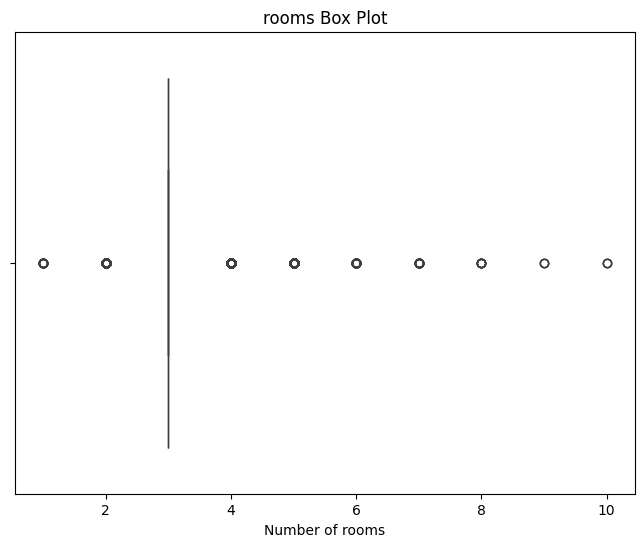

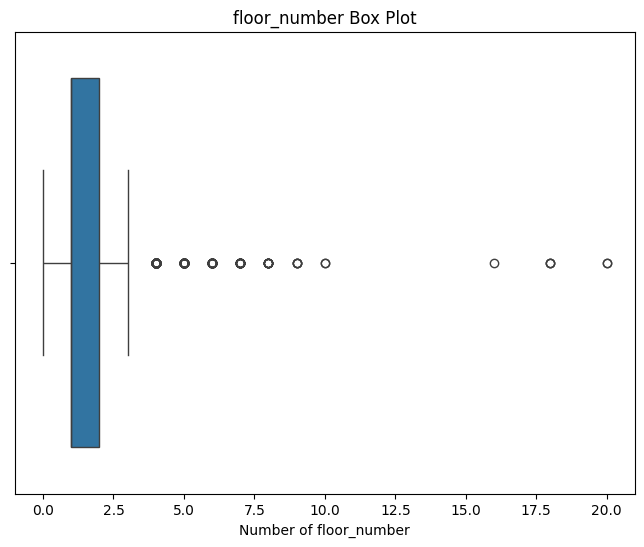

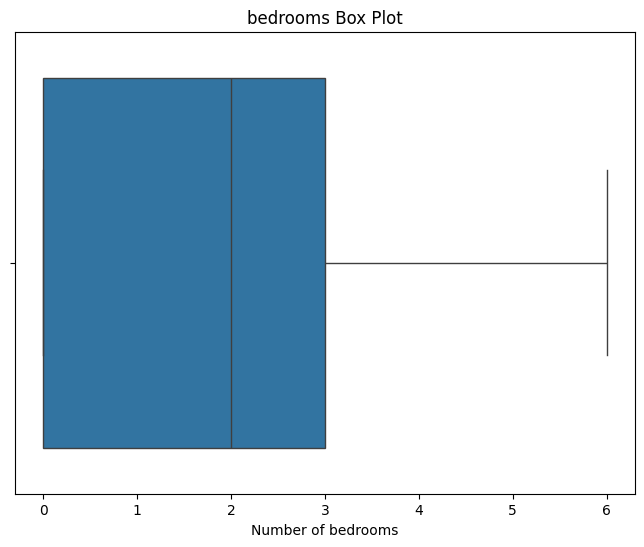

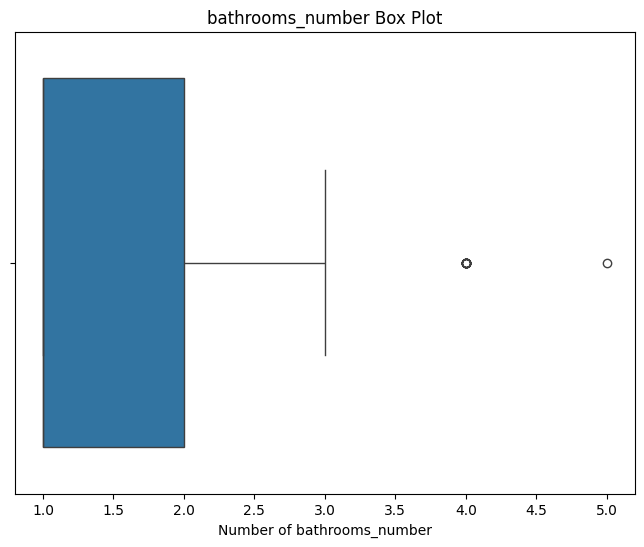

In [293]:
boxplot(df_clean,'rooms') 
boxplot(df_clean,'floor_number')
boxplot(df_clean,'bedrooms')
boxplot(df_clean,'bathrooms_number')

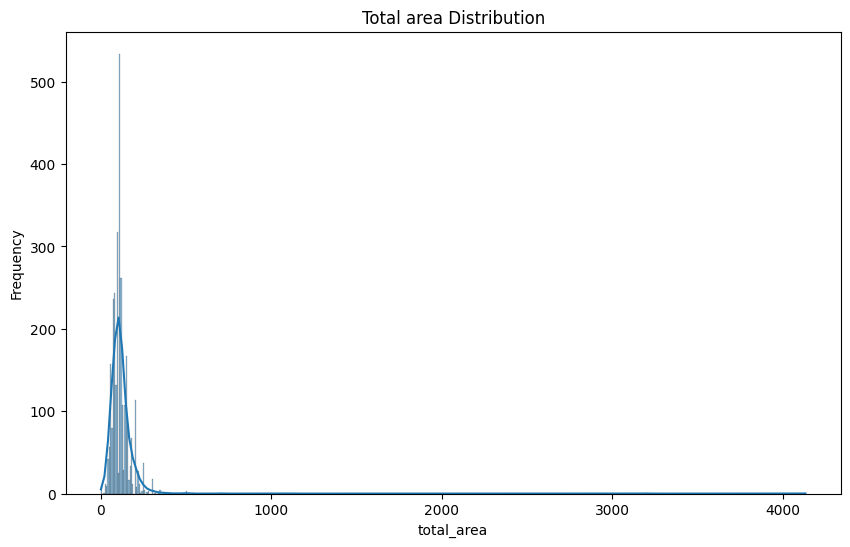

In [294]:
plot_distribution(df_clean['total_area'],'Total area Distribution','total_area')

In [295]:

print(df_clean.shape)
def remove_outliers_iqr(df, column, k=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
for col in ["total_area"]:
    df_clean = remove_outliers_iqr(df_clean, col)
    print(f"After IQR outlier removal on {col}: {df_clean.shape}")



(2985, 21)
After IQR outlier removal on total_area: (2861, 21)


In [296]:
def remove_outliers_zscore(df, column, threshold=3):
    # Calculate the Z-score for each data point
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    # Filter out the outliers
    return df[np.abs(z_scores) < threshold]

In [297]:

print(df_clean.shape)
for col in ['rooms','floor_number','bathrooms_number','bedrooms']:
    df_clean=remove_outliers_zscore(df_clean,col)
    print(df_clean.shape)


(2861, 21)
(2823, 21)
(2782, 21)
(2778, 21)
(2777, 21)


In [298]:
# Get the count of the minority class (Jour)
jour_count = df_clean[df_clean['payment_period'] == 'Jour'].shape[0]

# Get unique municipalities
all_municipalities = df_clean['municipality'].unique()

# Initialize an empty DataFrame to store our balanced sample
balanced_df = pd.DataFrame()

# First, include all 'Jour' records
jour_data = df_clean[df_clean['payment_period'] == 'Jour']
balanced_df = pd.concat([balanced_df, jour_data])

# Include all 'Semaine' records
semaine_data = df_clean[df_clean['payment_period'] == 'Semaine']
balanced_df = pd.concat([balanced_df, semaine_data])

# For 'Mois' category, sample strategically to preserve municipalities
mois_data = df_clean[df_clean['payment_period'] == 'Mois']

# Calculate how many samples we need from 'Mois'
mois_sample_size = jour_count

# Ensure each municipality is represented in the 'Mois' sample
mois_sample = pd.DataFrame()

# First, ensure at least one record from each municipality (if available)
for municipality in all_municipalities:
    municipality_mois = mois_data[mois_data['municipality'] == municipality]
    if not municipality_mois.empty:
        # Take at least one sample from each municipality
        mois_sample = pd.concat([mois_sample, municipality_mois.sample(min(1, len(municipality_mois)), random_state=42)])

# If we haven't reached our target sample size, add more records randomly
remaining_sample_size = mois_sample_size - len(mois_sample)
if remaining_sample_size > 0:
    # Exclude already sampled records
    remaining_mois = mois_data[~mois_data.index.isin(mois_sample.index)]
    if not remaining_mois.empty:
        additional_samples = remaining_mois.sample(remaining_sample_size, random_state=42)
        mois_sample = pd.concat([mois_sample, additional_samples])

# Combine all data
balanced_df = pd.concat([balanced_df, mois_sample])

# Shuffle the data
df_clean = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify that all municipalities are still represented
print(f"Number of unique municipalities after balancing: {df_clean['municipality'].nunique()}")
print(f"Original number of unique municipalities: {len(all_municipalities)}")

Number of unique municipalities after balancing: 69
Original number of unique municipalities: 69


In [299]:
print(df_clean.shape)
print(df_clean["municipality"].nunique())
df_clean['payment_period'].value_counts()

(743, 21)
69


payment_period
Mois       321
Jour       321
Semaine    101
Name: count, dtype: int64

## 3-Data visualization

<Axes: xlabel='price', ylabel='total_area'>

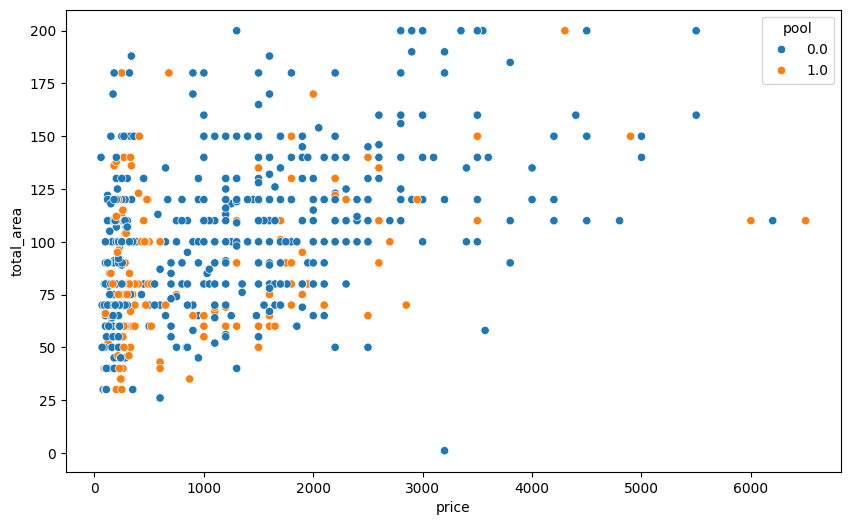

In [300]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_clean['price'], y=df_clean['total_area'],hue=df_clean['pool'])

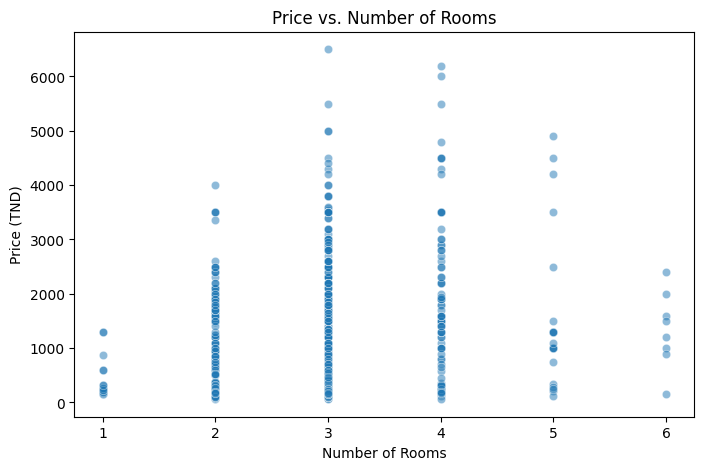

In [301]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='rooms', y='price', data=df_clean, alpha=0.5)
plt.title('Price vs. Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Price (TND)')
plt.show()

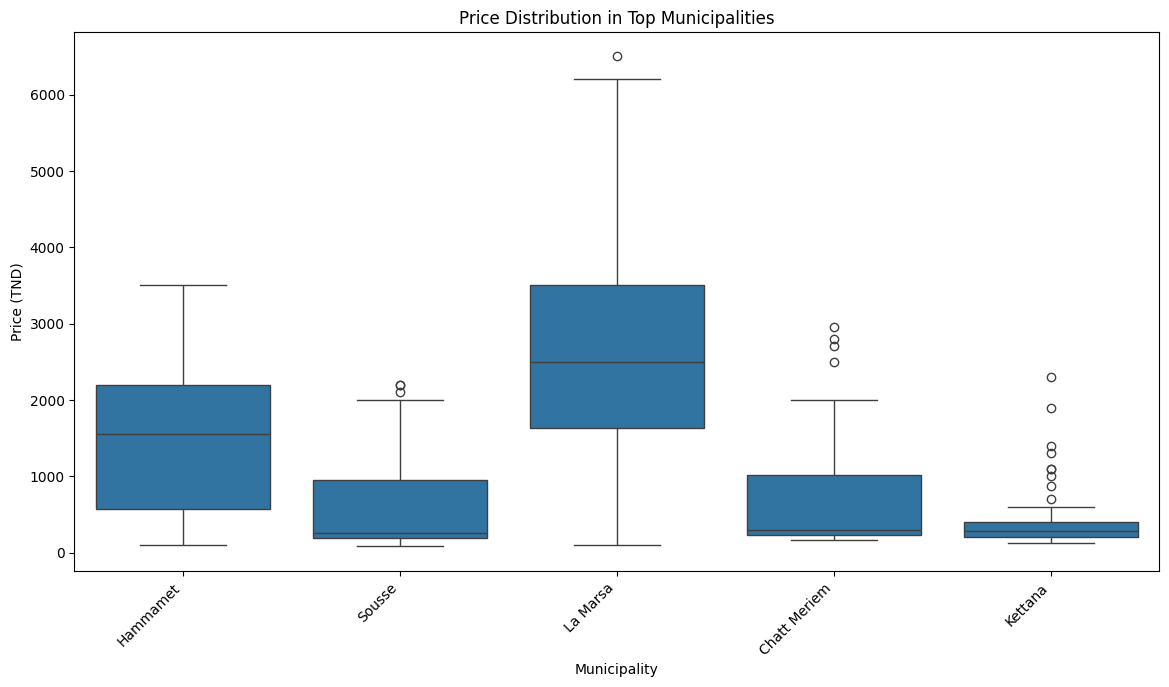

In [302]:
top_municipalities = df_clean.groupby('municipality')['price'].count().sort_values(ascending=False)
top_municipalities = top_municipalities[top_municipalities > 5].index[:5]
plt.figure(figsize=(14, 7))
sns.boxplot(x='municipality', y='price', 
            data=df_clean[df_clean['municipality'].isin(top_municipalities)])
plt.title('Price Distribution in Top Municipalities')
plt.xlabel('Municipality')
plt.ylabel('Price (TND)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [303]:
def count_figure(col):
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df_clean, x=col, palette='deep')
    plt.title('Distribution of Apartments by '+col)
    plt.ylabel('Number of Apartments')
    plt.tight_layout()
    plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


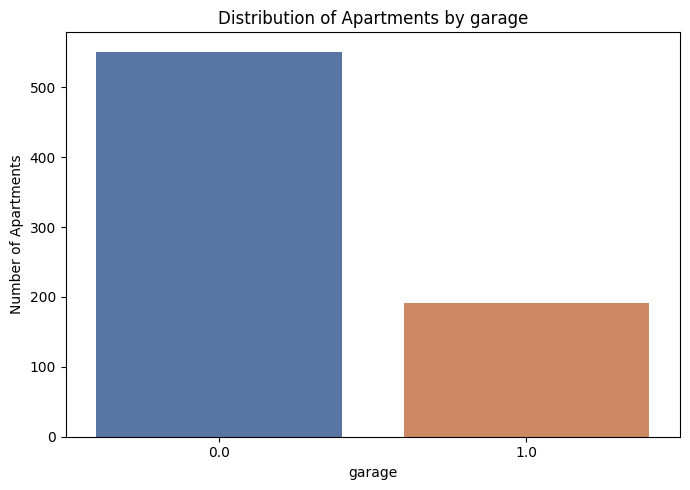

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


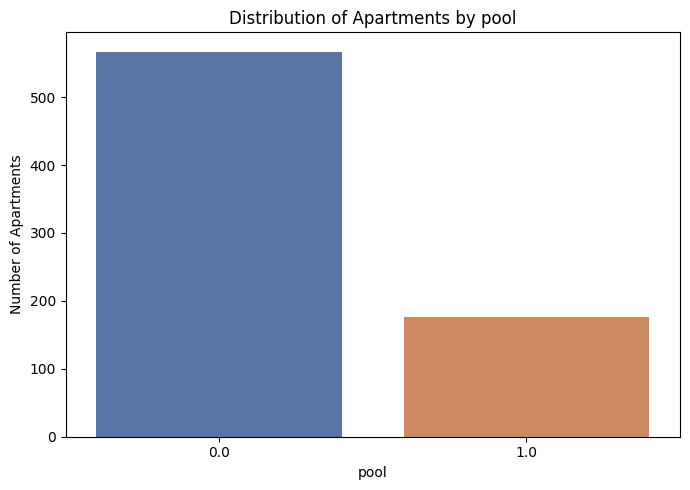

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


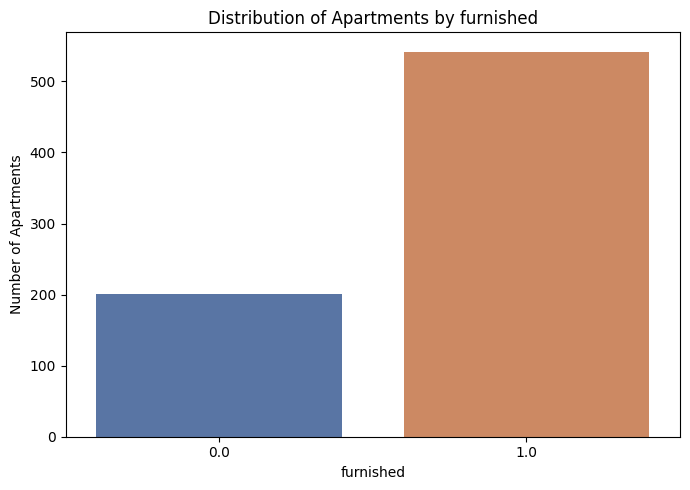

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


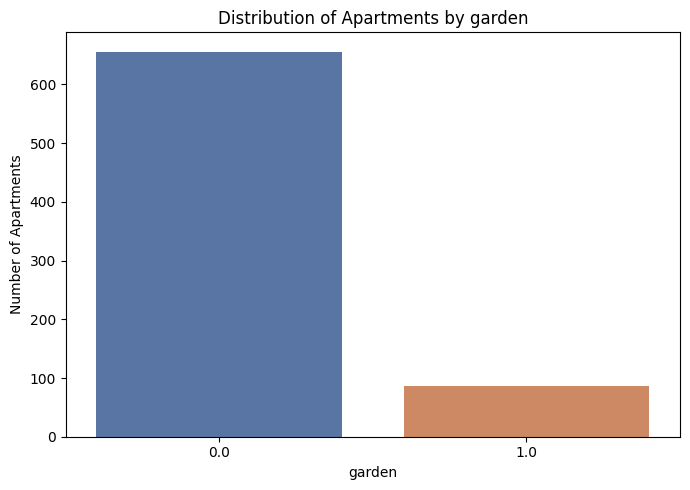

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


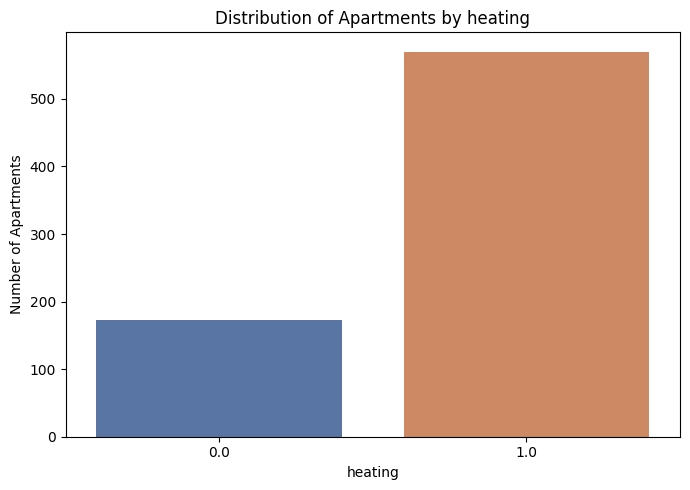

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


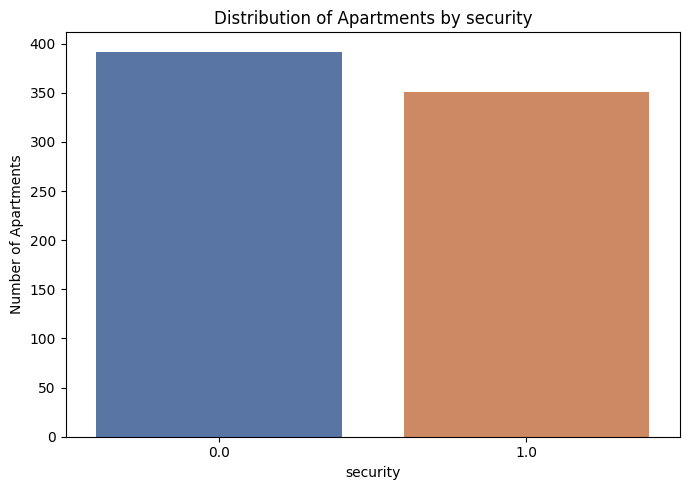

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


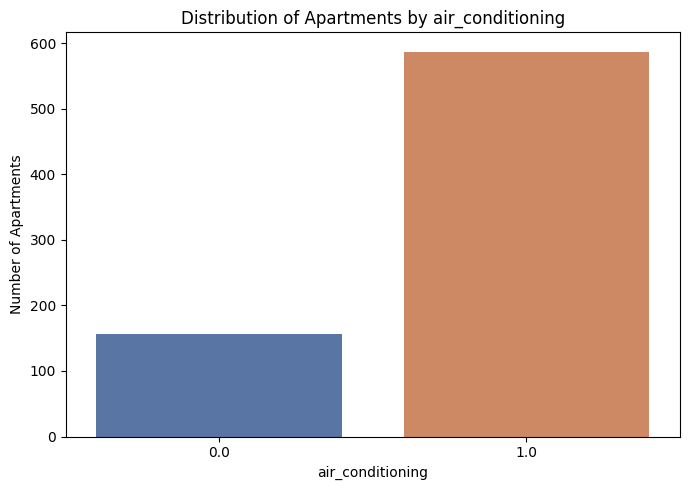

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


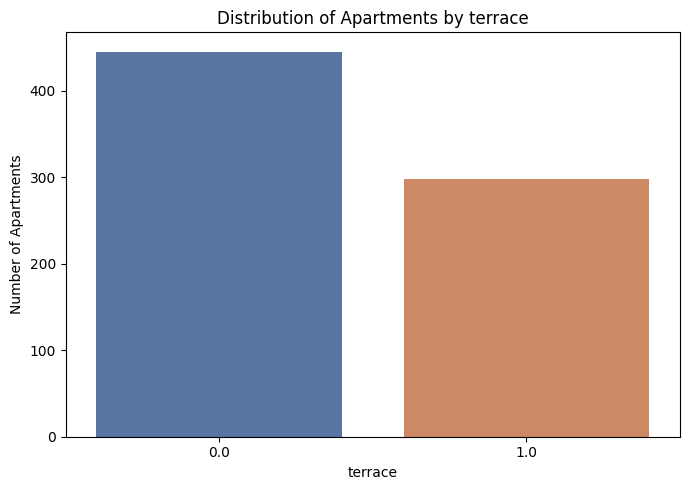

C:\Users\MSI\AppData\Local\Temp\ipykernel_7216\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


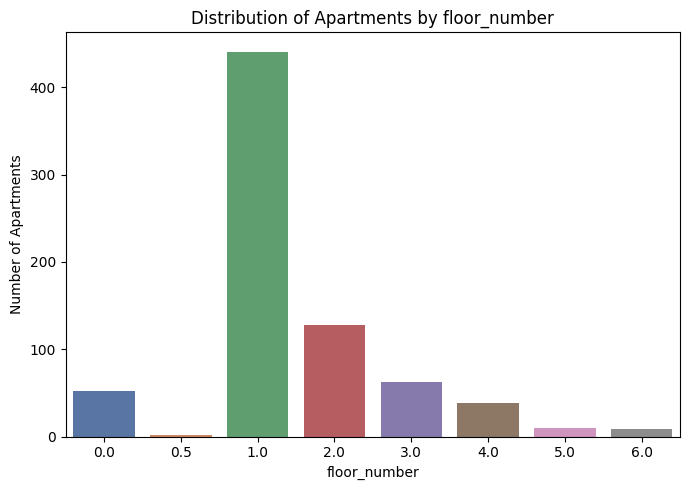

In [304]:
for col in ['garage','pool','furnished','garden','heating','security','air_conditioning','terrace','floor_number']:
    count_figure(col)

## 4-Feature engineering and selection

In [305]:
# Round latitude and longitude to 4 decimal places
df_clean['latitude'] = df_clean['latitude'].round(4)
df_clean['longitude'] = df_clean['longitude'].round(4)
# Check the rounded values
print(df_clean[['latitude', 'longitude']].head())

   latitude  longitude
0   36.4506    10.7350
1   36.8664    10.2914
2   36.4011    10.6146
3   36.3892    10.5525
4   35.8485    10.6154


now we are going to add some extra information about the address so we can better describe it
cause latitude and longitude are not enough

In [306]:
df_clean['governorate'].nunique()

18

In [307]:
municipality_governorate_description=pd.read_csv('municipality_governorate_description.csv')
municipality_governorate_description=municipality_governorate_description.drop(columns=
['municipality_avg_price','governorate_avg_price','governorate'])
municipality_governorate_description.head()

,municipality,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,Ajim (Djerba),mid_price_housing_area,high,mid_price_housing_area,high
1,Akouda,premium_housing_area,high,premium_housing_area,high
2,Ariana,premium_housing_area,high,premium_housing_area,high
3,Aïn Draham,affordable_housing_area,low,affordable_housing_area,high
4,Bembla-Mnara,affordable_housing_area,low,mid_price_housing_area,high


In [308]:
print(df_clean.shape)
df_clean=df_clean.merge(municipality_governorate_description,on='municipality',how='left')
print(df_clean.shape)
df_clean.head()

(743, 21)
(743, 25)


,price,address,total_area,rooms,terrace,elevator,furnished,air_conditioning,heating,security,...,garden,pool,payment_period,bathrooms_number,municipality,governorate,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,1200.0,Nabeul à Nabeul,100.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,Mois,1.0,Nabeul,Nabeul,premium_housing_area,high,mid_price_housing_area,high
1,2500.0,Les Jardins de Carthage à Le Kram,130.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.0,Mois,2.0,Le Kram,Tunis,premium_housing_area,high,premium_housing_area,high
2,1000.0,Hammamet Nord à Hammamet,110.0,5.0,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,Mois,1.0,Hammamet,Nabeul,premium_housing_area,high,mid_price_housing_area,high
3,1500.0,Hammamet Sud à Hammamet,80.0,2.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,Semaine,1.0,Hammamet,Nabeul,premium_housing_area,high,mid_price_housing_area,high
4,242.0,Sousse Khezama,80.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,Jour,1.0,Sousse,Sousse,premium_housing_area,high,premium_housing_area,high


In [309]:
df_clean=df_clean.drop(columns=['address','municipality','governorate'])
df_clean.head()

,price,total_area,rooms,terrace,elevator,furnished,air_conditioning,heating,security,floor_number,...,bedrooms,garage,garden,pool,payment_period,bathrooms_number,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,1200.0,100.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,1.0,0.0,0.0,Mois,1.0,premium_housing_area,high,mid_price_housing_area,high
1,2500.0,130.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,...,2.0,1.0,1.0,0.0,Mois,2.0,premium_housing_area,high,premium_housing_area,high
2,1000.0,110.0,5.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,Mois,1.0,premium_housing_area,high,mid_price_housing_area,high
3,1500.0,80.0,2.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,Semaine,1.0,premium_housing_area,high,mid_price_housing_area,high
4,242.0,80.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,...,0.0,0.0,0.0,0.0,Jour,1.0,premium_housing_area,high,premium_housing_area,high


In [310]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743 entries, 0 to 742
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            743 non-null    float64
 1   total_area                       743 non-null    float64
 2   rooms                            743 non-null    float64
 3   terrace                          743 non-null    float64
 4   elevator                         743 non-null    float64
 5   furnished                        743 non-null    float64
 6   air_conditioning                 743 non-null    float64
 7   heating                          743 non-null    float64
 8   security                         743 non-null    float64
 9   floor_number                     743 non-null    float64
 10  latitude                         742 non-null    float64
 11  longitude                        742 non-null    float64
 12  bedrooms              

In [311]:
df_clean=df_clean.dropna()

In [312]:
categorical_cols = ['payment_period','municipality_quality','municipality_quality_confidence',
                    'governorate_quality','governorate_quality_confidence'] 
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded.head()

,price,total_area,rooms,terrace,elevator,furnished,air_conditioning,heating,security,floor_number,...,garden,pool,bathrooms_number,payment_period_Mois,payment_period_Semaine,municipality_quality_mid_price_housing_area,municipality_quality_premium_housing_area,municipality_quality_confidence_low,governorate_quality_mid_price_housing_area,governorate_quality_premium_housing_area
0,1200.0,100.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,True,False,False,True,False,True,False
1,2500.0,130.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,...,1.0,0.0,2.0,True,False,False,True,False,False,True
2,1000.0,110.0,5.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,True,False,False,True,False,True,False
3,1500.0,80.0,2.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.0,0.0,1.0,False,True,False,True,False,True,False
4,242.0,80.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,...,0.0,0.0,1.0,False,False,False,True,False,False,True


In [313]:
df_encoded.columns

Index(['price', 'total_area', 'rooms', 'terrace', 'elevator', 'furnished',
       'air_conditioning', 'heating', 'security', 'floor_number', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool', 'bathrooms_number',
       'payment_period_Mois', 'payment_period_Semaine',
       'municipality_quality_mid_price_housing_area',
       'municipality_quality_premium_housing_area',
       'municipality_quality_confidence_low',
       'governorate_quality_mid_price_housing_area',
       'governorate_quality_premium_housing_area'],
      dtype='object')

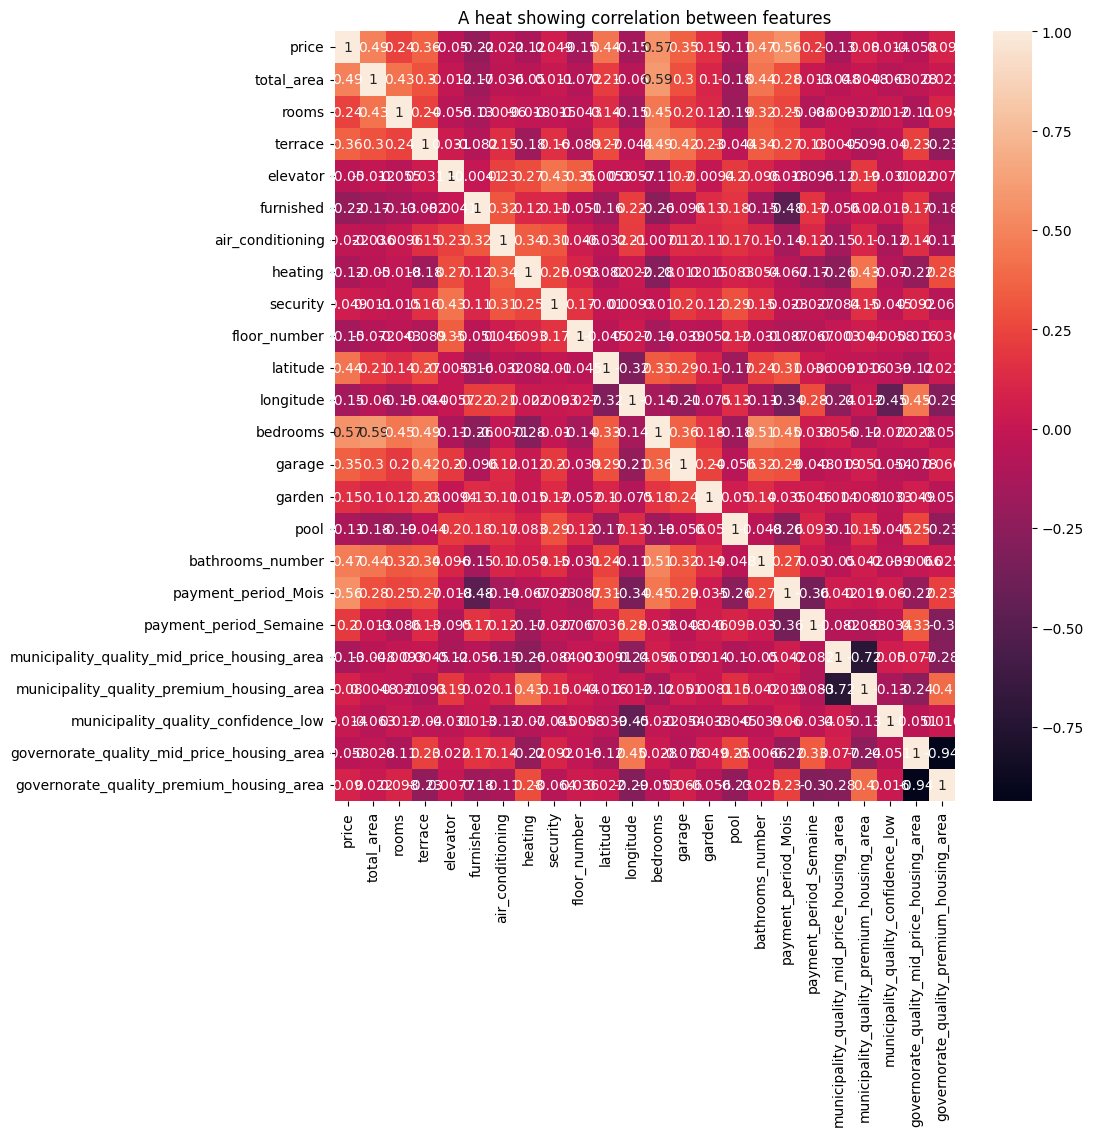

In [314]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_encoded.corr(), annot=True)
plt.title("A heat showing correlation between features")
plt.show()


In [315]:
"""
df_encoded.to_csv("apartment_location_clean_data.csv",index=False)
df_encoded=pd.read_csv('synthatic_data_apartement.csv')
df_encoded=df_encoded.dropna()
"""

'\ndf_encoded.to_csv("apartment_location_clean_data.csv",index=False)\ndf_encoded=pd.read_csv(\'synthatic_data_apartement.csv\')\ndf_encoded=df_encoded.dropna()\n'

## Modeling

In [316]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor

In [324]:
df=pd.read_csv('aparmtent_renting_synthatic.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2794 entries, 0 to 2793
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   2794 non-null   int64  
 1   price                                        2794 non-null   float64
 2   total_area                                   2794 non-null   int64  
 3   rooms                                        2794 non-null   int64  
 4   terrace                                      2794 non-null   int64  
 5   elevator                                     2794 non-null   int64  
 6   furnished                                    2794 non-null   int64  
 7   air_conditioning                             2794 non-null   int64  
 8   heating                                      2794 non-null   int64  
 9   security                                     2794 non-null   int64  
 10  

In [325]:
X=df.drop(columns=['price'],axis=1)
print(X.shape)
y=df['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

(2794, 24)


In [326]:
# Define the function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    
    print("Model: ",model_name)
    print(f"Training R²: {train_r2:.3f}, Test R²: {test_r2:.3f}")
    print(f"Training MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"R² Difference (Overfitting): {train_r2 - test_r2:.3f}")

In [199]:
def cross_val_evaluate(model):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-validation R² scores: {cv_scores}")
    print(f"Mean CV R² score: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV R² scores: {np.std(cv_scores):.4f}")

    # Get feature importances
    feature_importances = model.feature_importances_
    features = X_train.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()  # Display the most important feature at the top
    plt.tight_layout()
    plt.show()

 ### Linear regression

In [327]:
from sklearn.preprocessing import StandardScaler
lr=LinearRegression()
# Add StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test,"Linear Regression")

Model:  Linear Regression
Training R²: 0.685, Test R²: 0.660
Training MAE: 352.83, Test MAE: 369.07
R² Difference (Overfitting): 0.025


### Decision Tree

Starting hyperparameter search for Decision Tree...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': None}
Model:  Decision Tree
Training R²: 0.957, Test R²: 0.744
Training MAE: 72.03, Test MAE: 175.92
R² Difference (Overfitting): 0.213

Cross-validation R² scores: [0.78402006 0.85372602 0.78568243 0.8000468  0.78739804]
Mean CV R² score: 0.8022
Standard deviation of CV R² scores: 0.0264


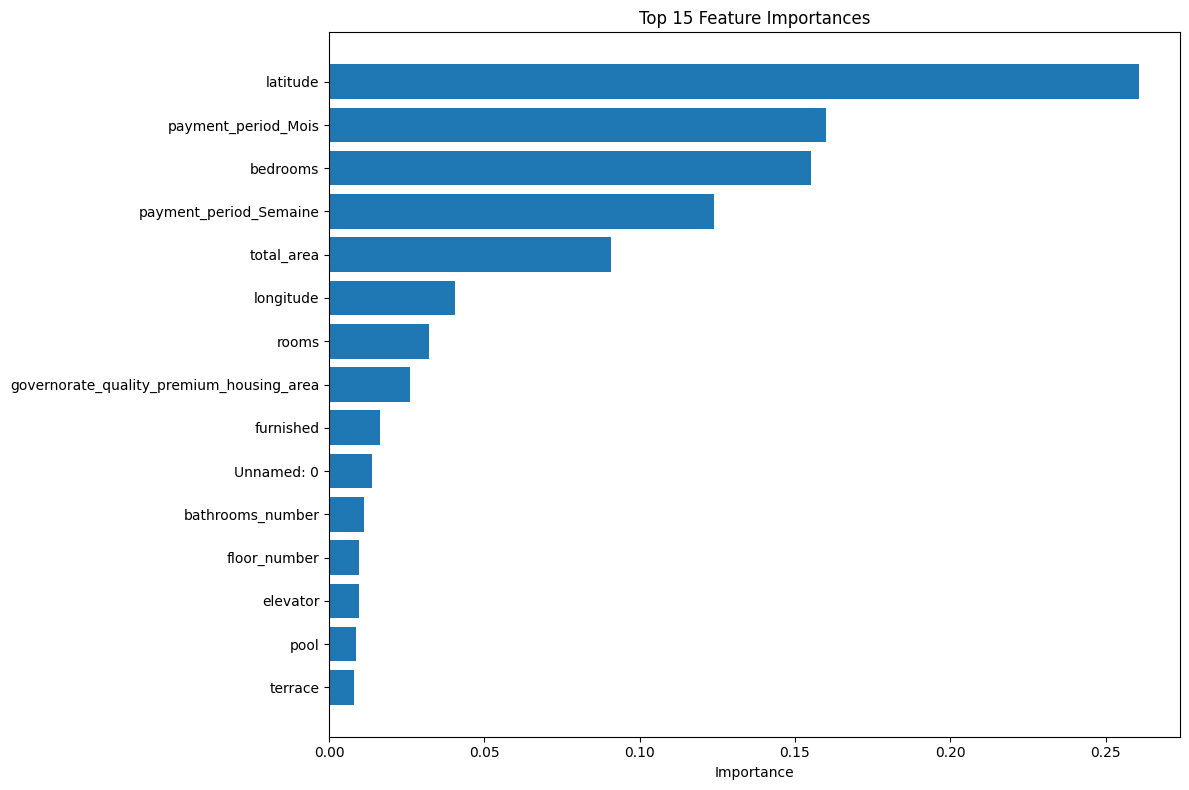

In [328]:
from sklearn.tree import DecisionTreeRegressor
# Define the parameter distribution for Decision Tree
param_dist = {
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Maximum depth of the tree
    'min_samples_split': [5, 10, 15, 20, 25],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]  # Number of features to consider when looking for the best split
}
# Create a base Decision Tree model
dt = DecisionTreeRegressor(random_state=42)
# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,   # Controls the verbosity of the output
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_absolute_error'  # Focus on error minimization
)
# Fit RandomizedSearchCV
print("Starting hyperparameter search for Decision Tree...")
dt_random.fit(X_train, y_train)
print("Hyperparameter search completed!")
# Get the best parameters and score
print(f"Best parameters: {dt_random.best_params_}")
# Create a model with the best parameters
best_dt = DecisionTreeRegressor(**dt_random.best_params_, random_state=42)
evaluate_model(best_dt, X_train, X_test, y_train, y_test, "Decision Tree")
cross_val_evaluate(best_dt)

### Rnadom forest

Starting hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'oob_score': True, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': 0.7, 'max_depth': 15, 'bootstrap': True}
Model:  Random forest
Training R²: 0.962, Test R²: 0.888
Training MAE: 83.12, Test MAE: 137.55
R² Difference (Overfitting): 0.075

Cross-validation R² scores: [0.89533085 0.89992337 0.89911826 0.89417697 0.89282107]
Mean CV R² score: 0.8963
Standard deviation of CV R² scores: 0.0028


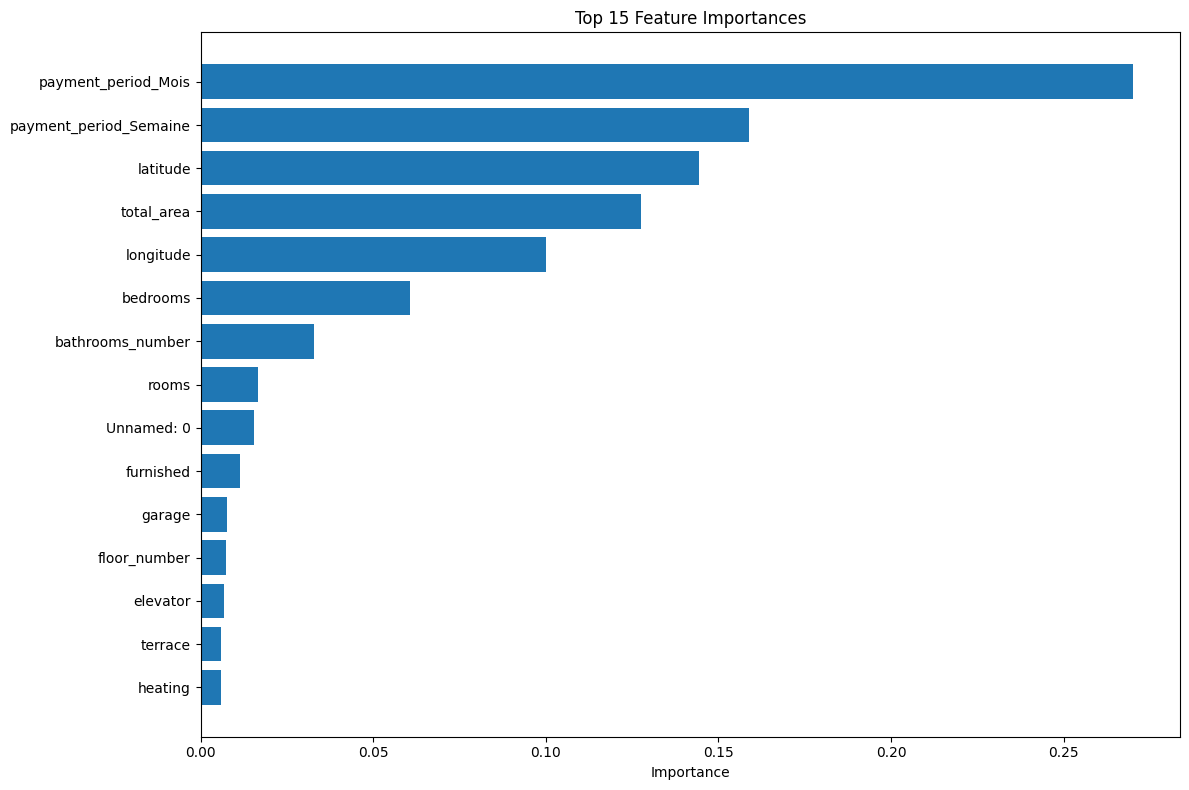

In [329]:
# Define the parameter distribution with more regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],  # Number of trees in the forest
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Maximum depth of each tree
    'min_samples_split': [5, 10, 15, 20, 25],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],  # Number of features to consider when looking for the best split
    'bootstrap': [True],  # Whether bootstrap samples are used when building trees
    'oob_score': [True],  # Whether to use out-of-bag samples to estimate the generalization error
    'max_samples': [0.7, 0.8, 0.9, None]  # Fraction of samples to draw from X to train each base estimator
}

# Create a base Random Forest model
rf = RandomForestRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,   # Controls the verbosity of the output
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_absolute_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search...")
rf_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {rf_random.best_params_}")

# Create a model with the best parameters
best_rf = RandomForestRegressor(**rf_random.best_params_, random_state=42)
evaluate_model(best_rf, X_train, X_test, y_train, y_test, "Random forest")
cross_val_evaluate(best_rf)

### GradientBoostingRegressor

Starting hyperparameter search for Gradient Boosting...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 8, 'learning_rate': 0.1, 'alpha': 0.5}
Best cross-validation MSE: 64271.06
Model:  Gradient boost regressor
Training R²: 1.000, Test R²: 0.934
Training MAE: 9.12, Test MAE: 111.34
R² Difference (Overfitting): 0.066

Cross-validation R² scores: [0.9180128  0.91696543 0.93322513 0.91448489 0.90046385]
Mean CV R² score: 0.9166
Standard deviation of CV R² scores: 0.0104


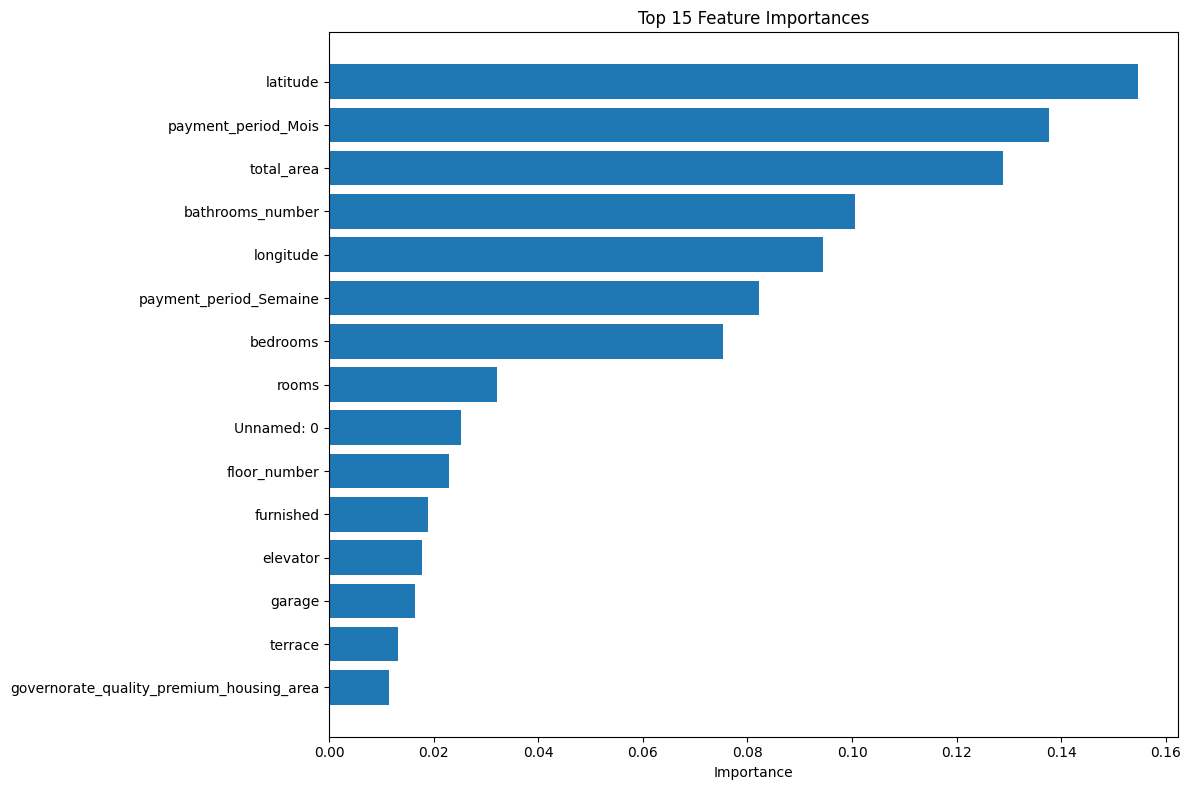

In [330]:
# Define the parameter distribution with regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 5, 6, 8],  # GBM typically uses shallower trees than RF
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # Similar to max_samples in RF
    'alpha': [0.1, 0.5, 0.9]  # Alpha for quantile loss (controls robustness)
}

# Create a base Gradient Boosting model
sgb = GradientBoostingRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
sgb_random = RandomizedSearchCV(
    estimator=sgb,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search for Gradient Boosting...")
sgb_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {sgb_random.best_params_}")
print(f"Best cross-validation MSE: {-sgb_random.best_score_:.2f}")
# Create a model with the best parameters
best_sgb = GradientBoostingRegressor(**sgb_random.best_params_, random_state=42)
evaluate_model(best_sgb, X_train, X_test, y_train, y_test,"Gradient boost regressor")
cross_val_evaluate(best_sgb)

In [135]:
"""
import pickle
with open('apartement_location_full.pkl','wb') as file:
    pickle.dump(best_sgb,file)
"""

"\nimport pickle\nwith open('apartement_location_full.pkl','wb') as file:\n    pickle.dump(best_sgb,file)\n"